# Image Search Engine

Given an input query image, searches catalog to retrieve top-k similar images in catalog

In [1]:
import keras
import numpy as np

Extract image features using a pre-trained model in keras

In [2]:
from keras.applications.vgg16 import VGG16, preprocess_input
base_model = VGG16(include_top=False, weights='imagenet', pooling='avg')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def extract_image_features(img_path):
  input_img = keras.utils.load_img(img_path, target_size=(224, 224))
  input_img = keras.utils.img_to_array(input_img)
  input_img = np.expand_dims(input_img, axis=0)

  input_img = preprocess_input(input_img)
  features = base_model.predict(input_img)
  feature_vector = features.flatten()
  return feature_vector / np.linalg.norm(feature_vector)

Load the image catalog and run feature extractor

In [ ]:
DIR = 'image-search'
!unzip image-search.zip

In [ ]:
import os
feature_matrix = []
file_names = []
for file in os.listdir(DIR):
  if file.endswith('.jpg'):
    img_path = os.path.join(DIR, file)
    features = extract_image_features(img_path)
    feature_matrix.append(features)
    file_names.append(img_path)

In [6]:
feature_matrix = np.array(feature_matrix)
feature_matrix.shape

(264, 512)

Image similarity is computed using K Nearest Neighbor method in Scikit-Learn

In [7]:
from sklearn.neighbors import NearestNeighbors
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(feature_matrix)

NearestNeighbors(metric='cosine')

Pass query image to retrieve top-5 similar images from catalog

In [8]:
def image_search(query_image):
  query_features = extract_image_features(query_image)
  distances, indices = knn.kneighbors([query_features])
  return distances, indices

In [9]:
dist, ind = image_search("test-image.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


Plot results showing top-5 most similar images

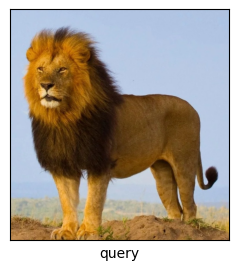

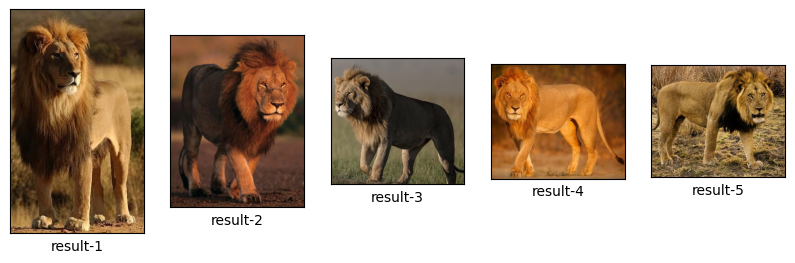

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))

# input query image
plt.subplot(1, 1, 1)
plt.imshow(plt.imread("test-image.jpg"))
plt.xticks([])
plt.yticks([])
plt.xlabel("query")

# top-5 search results from catalog retrieved by knn
l = 1
plt.figure(figsize=(10, 10))
for k in ind[0]:
  plt.subplot(1, 5, l)
  plt.imshow(plt.imread(file_names[k]))
  plt.xticks([])
  plt.yticks([])
  plt.xlabel("result-" + str(l))
  l += 1